# 言語モデル

言語モデルの概要やそれを用いた文章生成について。

In [1]:
import random

import torch
import matplotlib.pyplot as plt
import japanize_matplotlib
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM


---

## 言語モデル

*Language Model*

言語モデルとは、単語の並びに関する確率モデルである。

$$
p(w_1, w_2, ..., w_n)
$$

言語モデルは、単語の並び（文章）に確率を割り当てる。単語の並びは以後**単語列**と呼ぶことにしよう。言語モデルはNLPの分野で広く使われており、最近では主に文章生成に使われている。特に近年、かなり人間に近い文章を生成できるすげーモデルがLLM (Large Language Model)として一世を風靡している。

### 最も簡単な言語モデル

イメージをつかむため、まずは最も簡単な言語モデルを見てみよう。

言語モデルとは単語列に対して確率を割り当てるモデルであった。この確率を割り当てるアルゴリズムを出来る限りシンプルにしたモデルを考える。具体的にどうするかというと、ランダムにする。いかなる単語列に対してランダムな確率を割り当てるモデルということ。実際に作ってみよう。

In [2]:
# 単語列を入力として、確率を出力する関数
def language_model(sequence):
    prob = random.random() # 0 ~ 1 のランダムな値
    return prob

できた。使ってみよう。適当な単語列を入力してみる。

In [3]:
sequence = "明日は晴れるといいな"
prob = language_model(sequence)
prob

0.3900728095650663

ランダムな確率が出力された。これが最も簡単な言語モデルである。

余談

本来は単語列に対して確率が一意であってほしいため、実行毎にランダムな確率を返すこのプログラムは言語モデル実装として不適切である。


---

## 言語モデルを用いた文章生成

前節では入力された単語列に対してなんらかの確率を割り当てる「言語モデル」と呼ばれるモデルを学んだ。では、このモデルを用いて文章を生成するにはどうすればいいだろう。

答えは簡単。確率が高い単語の並びを選択するだけ。

モデルは「語彙」を持っており、その語彙から作れる全ての単語列に対して確率を割り当て、最も高い単語列を出力する。その単語列が、モデルが生成した文章となる。

さて、今、モデルが持っている語彙から作れる全ての単語列に確率を割り当てると説明した。しかしこれは現実的ではない。単語数に制限を設けない場合、ある語彙から作れる単語列の数は無限となり、また仮に単語数を制限したとしても、単語数に応じて単語列の数は指数的に増加するため、膨大な量となる。

そこで、**与えられた文脈**と持っている語彙から作れる単語列で考える。

例えば、モデルが以下の語彙を持っているとする。

- 今日
- 天気
- おいしい
- は
- いい

ここで、「今日 は いい」という単語列があったとする。このとき、この単語列と語彙から作れる文章を以下とする。

- 今日 は いい 今日
- 今日 は いい 天気
- 今日 は いい おいしい
- 今日 は いい は
- 今日 は いい いい

単語列の末尾に単語を1つ追加しただけだ。

これらに対して言語モデルで確率を割り当て、最も確率の高い単語列を出力する。そして、出力された単語列を再度モデルに与え、同様に単語列を生成する。これを繰り返すことで文章を生成する。これが、言語モデルを用いた文章生成である。

以上を踏まえると、文章生成における言語モデルの役割は「次の単語の予測」とも見て取れる。文章生成においては、与えられた文脈に続く単語を予測するモデルが言語モデルとなる。言語モデルが予測した単語を文章に追加し、その文章を再度言語モデルに与えて次の単語を予測し...と繰り返すことで文章を生成する。このようなモデルは**自己回帰（AR; Autoregressive）モデル**と呼ばれる。

なお、厳密には、言語モデルが予測するものは次の単語ではなくその確率分布である。次の単語は確率分布からのサンプリングによって得る。言語モデルは以下のように記述できる。

$$
p(w_t|w_{<t}) = p(w_t|w_{t-1}, w_{t-2}, \dots, w_1)
$$

ある時刻$t$における単語$w_t$の確率分布$p(w_t)$を$t$より前の単語列$w_{<t}=w_1, w_2, \dots, w_{t-1}$から決定する。

では、この手法に基づいた言語モデルを作っていこう。

与えられた文脈から次の単語の確率分布を予測し、それに基づいて次の単語をサンプリングするモデルを作る。確率分布はランダムとする。

In [4]:
from typing import List

class LanguageModel:
    def __init__(self, vocab: List[str]):
        self.vocab = vocab # 語彙
        self.n_vocab = len(vocab) # 語彙数

    def __call__(self, context): # 文脈を受け取って次の単語を出力する
        weights = [random.random() for _ in range(self.n_vocab)]
            # 0 ~ 1 のランダムな値を語彙の数だけ生成
        dist = [weight / sum(weights) for weight in weights]
            # 正規化（確率分布に変換）
        next_word, = random.choices(self.vocab, weights=dist)
            # 確率分布に従って単語をサンプリング
        return next_word

できた。

適当に語彙と文脈を与えて次の単語を出力させてみよう。

In [5]:
vocab = ["今日", "天気", "おいしい", "は", "いい"] # 語彙
model = LanguageModel(vocab) # 言語モデル

context = "今日はいい" # 文脈
word = model(context) # 次の単語をサンプリング
word

'は'

この単語を文脈に追加して、再度次の単語を出力させる。

In [6]:
context = "今日はいい" + word # 得られた単語を文脈に追加
print(context) # 文脈
word = model(context) # 次の単語をサンプリング
word # 次の単語

今日はいいは


'今日'

これを繰り返せば文章が出来そうだ。やってみよう。

In [7]:
n_words = 10 # 生成する単語数

for _ in range(n_words):
    word = model(context) # 次の単語を予測
    context += word # 文脈に単語を追加

context

'今日はいいは今日今日は今日はおいしいおいしいおいしいおいしい今日'

出来た。これが言語モデルによる文章生成である。


---

## 学習済み言語モデルを体験する

ランダムな確率を割り当てるだけでは自然な文章は生成されないが、適切な確率を割り当てるように最適化された言語モデルであれば、かなり自然な文章を生成できる。実際にやってみる。huggingfaceの`transformers`というライブラリを使う。

In [8]:
from transformers import pipeline

# 適当な日本語の事前学習済みモデルをダウンロード
model_id = "abeja/gpt2-large-japanese"
generator = pipeline("text-generation", model=model_id)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Device set to use mps:0


In [9]:
# 文脈を与え、続きを生成させる
outputs = generator("人工知能とは、", do_sample=False, temperature=None)
print(outputs[0]["generated_text"])

人工知能とは、コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、 より高度な処理能力を持ったコンピュータのこと。 人工知能は、 コンピュータの処理能力の向上により、 人間の知能を超えるような、


モード崩壊起こしてるけど、局所的に見れば自然な文章になっている。

文章生成の方法は先ほど説明した通りで、与えられた文脈から次の単語を予測し、その単語を文脈に追加して...を繰り返す。この処理を自分で書いてみて、どのように単語を予測しているか確認してみよう。

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

ニューラルネットを用いた言語モデルでは単語をIDに変換する必要がある。単語ごとに分割&ID割り振りはトークナイザーと呼ばれるモデルが担う。

In [11]:
input_text = "人工知能とは、"
input_ids = tokenizer(input_text).input_ids
for input_id in input_ids:
    print(f"{input_id}\t{tokenizer.convert_ids_to_tokens(input_id)}")

7	▁
28158	人工知能
339	とは
8	、
2	</s>


1文字目このトークナイザ固有の特殊な文字で、文章のはじめに必ず入る。最後の単語も特殊なもので、文章の終わりを示す。

*なおトークナイザが扱う単位は厳密には単語ではなくサブワードと呼ばれるものである。このあたりは後の章で詳しく説明する。

最後の単語を除いたID列をモデルに与え、次の単語の確率分布を得ると次のようになる。

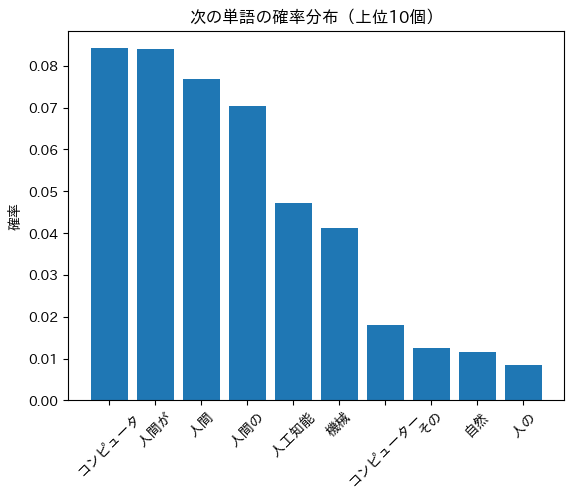

In [12]:
import torch
import matplotlib.pyplot as plt
import japanize_matplotlib

input_ids = input_ids[:-1]
logits = model(input_ids=torch.tensor([input_ids])).logits
next_token_logits = logits[0, -1]
probs = torch.softmax(next_token_logits, dim=-1)

top_10 = torch.topk(probs, k=10)
top_10_indices = top_10.indices.tolist()
top_10_probs = top_10.values.tolist()
top_10_tokens = [tokenizer.convert_ids_to_tokens(i) for i in top_10_indices]

plt.bar(top_10_tokens, top_10_probs)
plt.title("次の単語の確率分布（上位10個）")
plt.ylabel("確率")
plt.xticks(rotation=45)
plt.show()


全ての語彙（32000個）で行うと見えなくなるので、上位10個だけ表示した。「コンピュータ」が一番高くなっていることがわかる。この言語モデルは、「人工知能とは、」の後に「コンピュータ」と続く可能性が最も高いと予測しているということ。

この「コンピュータ」という単語を文脈に追加し、再度次の単語の確率分布を取得する。

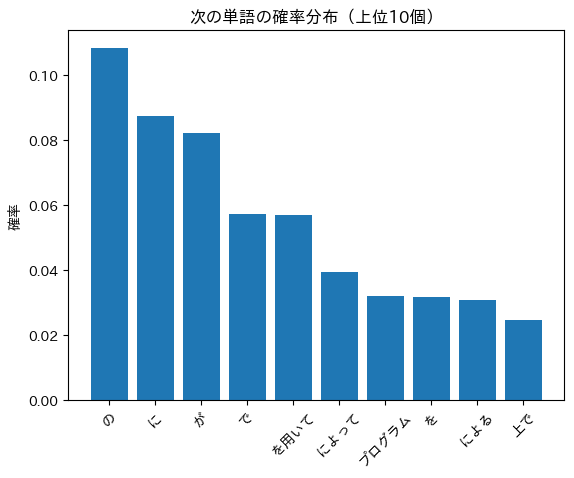

In [13]:
next_token_id = top_10_indices[0]
input_ids += [next_token_id]
logits = model(input_ids=torch.tensor([input_ids])).logits
next_token_logits = logits[0, -1]
probs = torch.softmax(next_token_logits, dim=-1)

top_10 = torch.topk(probs, k=10)
top_10_indices = top_10.indices.tolist()
top_10_probs = top_10.values.tolist()
top_10_tokens = [tokenizer.convert_ids_to_tokens(i) for i in top_10_indices]

plt.bar(top_10_tokens, top_10_probs)
plt.title("次の単語の確率分布（上位10個）")
plt.ylabel("確率")
plt.xticks(rotation=45)
plt.show()

「の」が一番高くなっている。これを再度に文脈に追加し、次の単語を予測し、と適当に繰り返すと、文章が生成できる。

In [14]:
print(tokenizer.decode(input_ids), end="")
for _ in range(100):
    logits = model(input_ids=torch.tensor([input_ids])).logits
    next_token_logits = logits[0, -1]
    probs = torch.softmax(next_token_logits, dim=-1)
    next_token_id = torch.argmax(probs).item()
    print(tokenizer.decode([next_token_id]), end="")
    input_ids.append(next_token_id)

人工知能とは、コンピュータの処理能力を向上させるために、人間に学習させる技術のことである。人工知能は、人間に学習させる技術である。人工知能は、コンピュータの処理能力を向上させるために、人間に学習させる技術である。人工知能は、コンピュータの処理能力を向上させるために、人間に学習させる技術である。人工知能は、コンピュータの処理能力を向上させるために、人間に学習させる技術である。人工知能は、コンピュータの処理能力を向上させるために、人間に学習させる技術である。人工知能は、

適当に100回繰り返した。決定的な生成手法を用いているため、`pipeline`を用いたときと同じ文章が生成される、はずなのだが、違う文章が生成されてしまった。特殊トークンの与え方が違ったりするのかな。まあこんな感じで文章生成ができるということがわかればオッケー。

次章から、このような言語モデルを自分で作っていく。